# MNIST Digit Classifier
This notebook explores the dataset, trains the model and visualises results.

In [10]:
#importing the libraries
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
import json

#directory where the data is stored
DATA_DIR = '../data'
#defining transformation to apply on the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(DATA_DIR, train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)
print(f'Train: {len(train_ds):,} samples ,  Test: {len(test_ds):,} samples')

Train: 60,000 samples ,  Test: 10,000 samples


## 1 · Sample Images

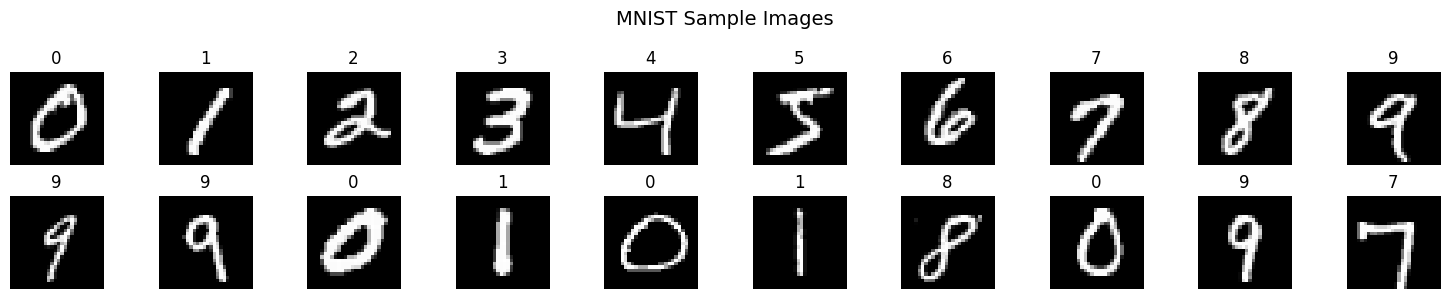

In [2]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for digit in range(10):
    idx = next(i for i, (_, y) in enumerate(train_ds) if y == digit)
    img, label = train_ds[idx]
    axes[0, digit].imshow(img.squeeze(), cmap='gray')
    axes[0, digit].set_title(str(label))
    axes[0, digit].axis('off')

# Random samples
for i in range(10):
    idx = np.random.randint(len(train_ds))
    img, label = train_ds[idx]
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(str(label))
    axes[1, i].axis('off')

plt.suptitle('MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## 2 · Class Distribution

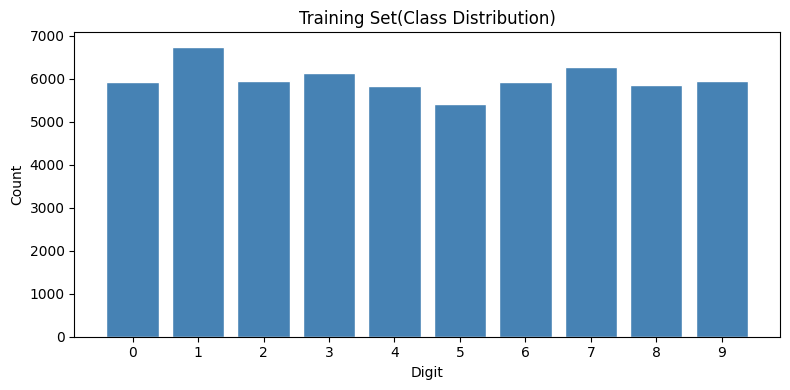

{0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


In [11]:
labels = [y for _, y in train_ds]
counts = np.bincount(labels)

plt.figure(figsize=(8, 4))
plt.bar(range(10), counts, color='steelblue', edgecolor='white')
plt.xlabel('Digit'); plt.ylabel('Count')
plt.title('Training Set(Class Distribution)')
plt.xticks(range(10))
plt.tight_layout()
plt.show()
print({i: int(c) for i, c in enumerate(counts)})

## 3 · Training (run train.py first, then visualise history)

In [ ]:
import subprocess 
import sys

result = subprocess.run(
    [sys.executable, "train.py"],
    capture_output=True,
    text=True
)

print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)

STDOUT:
 Using device: cpu
Epoch 01/10 â”‚ Train Loss: 0.1712  Acc: 0.9474 â”‚ Test  Loss: 0.0439  Acc: 0.9854
Epoch 02/10 â”‚ Train Loss: 0.0604  Acc: 0.9818 â”‚ Test  Loss: 0.0310  Acc: 0.9886
Epoch 03/10 â”‚ Train Loss: 0.0437  Acc: 0.9869 â”‚ Test  Loss: 0.0261  Acc: 0.9913
Epoch 04/10 â”‚ Train Loss: 0.0363  Acc: 0.9885 â”‚ Test  Loss: 0.0245  Acc: 0.9912
Epoch 05/10 â”‚ Train Loss: 0.0303  Acc: 0.9903 â”‚ Test  Loss: 0.0249  Acc: 0.9912
Epoch 06/10 â”‚ Train Loss: 0.0162  Acc: 0.9952 â”‚ Test  Loss: 0.0216  Acc: 0.9932
Epoch 07/10 â”‚ Train Loss: 0.0152  Acc: 0.9950 â”‚ Test  Loss: 0.0181  Acc: 0.9943
Epoch 08/10 â”‚ Train Loss: 0.0114  Acc: 0.9961 â”‚ Test  Loss: 0.0218  Acc: 0.9935
Epoch 09/10 â”‚ Train Loss: 0.0103  Acc: 0.9968 â”‚ Test  Loss: 0.0199  Acc: 0.9938
Epoch 10/10 â”‚ Train Loss: 0.0098  Acc: 0.9969 â”‚ Test  Loss: 0.0225  Acc: 0.9931

âœ… Training complete! Best test accuracy: 0.9943

STDERR:
 


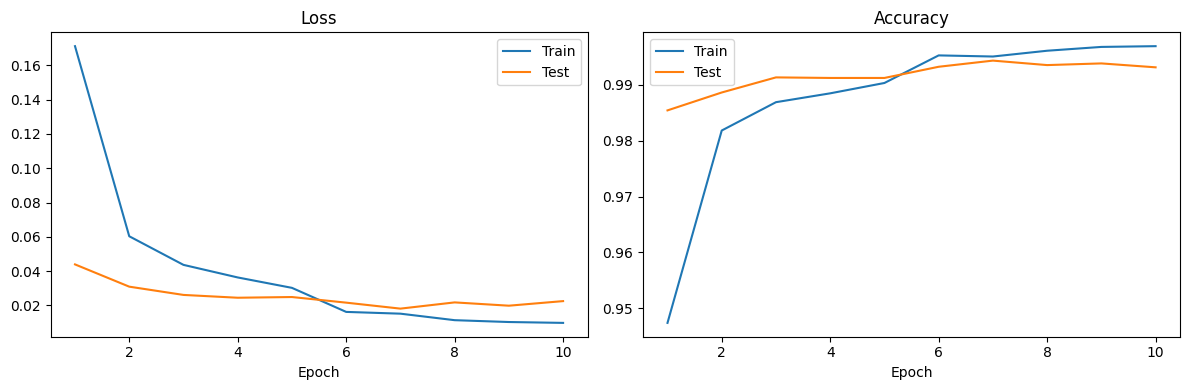

Best test accuracy: 0.9943


In [5]:
with open('models/history.json') as f:
    history = json.load(f)

epochs = range(1, len(history['train_acc']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['test_loss'],  label='Test')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['test_acc'],  label='Test')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()
print(f"Best test accuracy: {max(history['test_acc']):.4f}")

## 4 · Confusion Matrix

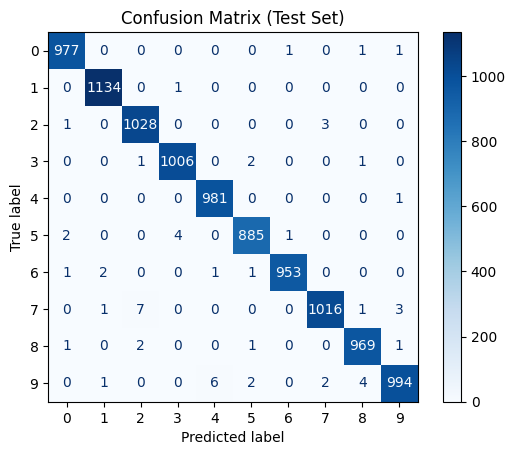

In [13]:
import sys; sys.path.insert(0, '..')
from train import MNISTNet
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MNISTNet().to(device)
model.load_state_dict(torch.load('models/best_model.pth', map_location=device))
model.eval()

loader = DataLoader(test_ds, batch_size=256, shuffle=False)
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        all_preds.extend(model(imgs).argmax(1).cpu().tolist())
        all_labels.extend(lbls.tolist())

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.show()